In [1]:
# ==========================================================
# CELL 1
# Import all required libraries
# ==========================================================

print("Starting cell #1")

import os
import gc
import re
import json
import copy
import math
import pickle
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
from torch.ao.quantization import quantize_dynamic

from transformers import (
    AutoConfig,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    XLMRobertaConfig,
    XLMRobertaModel,
    get_linear_schedule_with_warmup
)

warnings.filterwarnings("ignore")

print("Executed cell #1")

Starting cell #1
Executed cell #1


In [2]:
# ==========================================================
# CELL 2
# Set Kaggle dataset file names and dataset discovery hint
# ==========================================================

print("Starting cell #2")

TRAIN_FILENAME = "train.csv"
VAL_FILENAME = "validation.csv"
TEST_FILENAME = "test.csv"

# Change this only if your Kaggle input folder uses another name
DATASET_NAME_HINT = "dataset"

print("Executed cell #2")

Starting cell #2
Executed cell #2


In [3]:
# ==========================================================
# CELL 3
# Set model hyperparameters, training settings, and save directory
# Lightweight final student + faster KD training
# ==========================================================

print("Starting cell #3")

# -----------------------------
# Teacher / tokenizer backbone
# -----------------------------
TEACHER_MODEL_NAME = "xlm-roberta-base"

# -----------------------------
# Student architecture
# Truncated pretrained XLM-R:
# keep only first 6 transformer layers
# -----------------------------
STUDENT_NUM_LAYERS = 6
STUDENT_PROJECTION_DIM = 256
DROPOUT = 0.20

# -----------------------------
# Sequence length
# Auto-estimate from data, then cap
# -----------------------------
AUTO_FIND_MAX_LENGTH = True
FIXED_MAX_LENGTH = 96
MAX_LENGTH_PERCENTILE = 95
MAX_LENGTH_CAP = 96
MIN_MAX_LENGTH = 48
LENGTH_SAMPLE_PER_LANGUAGE = 15000
TOKENIZATION_BATCH_SIZE = 2048

# -----------------------------
# Batch / speed
# Teacher uses flat multilingual samples
# Student uses triplet multilingual rows
# -----------------------------
PER_GPU_BATCH_SIZE_TEACHER = 24
PER_GPU_BATCH_SIZE_STUDENT = 6
NUM_WORKERS = 4
USE_AMP = True
GRAD_ACCUM_STEPS = 1
GRAD_CLIP = 1.0

# -----------------------------
# Teacher training
# -----------------------------
TEACHER_EPOCHS = 3
TEACHER_LR = 2e-5

# -----------------------------
# Student training
# -----------------------------
STUDENT_EPOCHS = 6
STUDENT_FREEZE_EPOCHS = 1
STUDENT_FREEZE_FIRST_N_LAYERS = 2

STUDENT_ENCODER_LR = 1.2e-5
STUDENT_HEAD_LR = 6e-5
LAYERWISE_LR_DECAY = 0.90
WEIGHT_DECAY = 0.01
LABEL_SMOOTHING = 0.05
WARMUP_RATIO = 0.10

# -----------------------------
# Student losses
# total = CE + a*KD + b*RowAlign + c*SupCon + d*Consistency
# -----------------------------
KD_TEMPERATURE = 2.0
SUPCON_TEMPERATURE = 0.07
CONSISTENCY_TEMPERATURE = 1.5

KD_WEIGHT = 0.45
ROW_ALIGN_WEIGHT = 0.05
SUPCON_WEIGHT = 0.05
CONSISTENCY_WEIGHT = 0.05

# -----------------------------
# Teacher logits caching
# -----------------------------
TEACHER_CACHE_BATCH_SIZE = 32

# -----------------------------
# Early stopping
# -----------------------------
EARLY_STOPPING_PATIENCE = 2

# -----------------------------
# Repro / paths
# -----------------------------
SEED = 42
SAVE_DIR = "/kaggle/working/lightweight_multilingual_emotion_kd_student"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Executed cell #3")

Starting cell #3
Executed cell #3


In [4]:
# ==========================================================
# CELL 4
# Set random seeds for reproducibility
# ==========================================================

print("Starting cell #4")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print("Executed cell #4")

Starting cell #4
Executed cell #4


In [5]:
# ==========================================================
# CELL 5
# Check GPUs and configure effective batch size
# Also enable AMP and CUDA speed flags
# ==========================================================

print("Starting cell #5")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
MULTI_GPU = GPU_COUNT > 1

print("Using device:", device)
print("GPU count:", GPU_COUNT)

if torch.cuda.is_available():
    for i in range(GPU_COUNT):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

TEACHER_BATCH_SIZE = PER_GPU_BATCH_SIZE_TEACHER * max(1, GPU_COUNT)
STUDENT_BATCH_SIZE = PER_GPU_BATCH_SIZE_STUDENT * max(1, GPU_COUNT)
AMP_ENABLED = USE_AMP and (device.type == "cuda")

print("Teacher batch size:", TEACHER_BATCH_SIZE)
print("Student batch size:", STUDENT_BATCH_SIZE)
print("AMP enabled:", AMP_ENABLED)
print("Multi-GPU enabled:", MULTI_GPU)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")

print("Executed cell #5")

Starting cell #5
Using device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Teacher batch size: 48
Student batch size: 12
AMP enabled: True
Multi-GPU enabled: True
Executed cell #5


In [6]:
# ==========================================================
# CELL 6
# Define Kaggle CSV path resolver and required dataset columns
# ==========================================================

print("Starting cell #6")

REQUIRED_COLUMNS = ["Label", "Bengali", "Banglish", "English"]

def resolve_kaggle_csv(filename, dataset_name_hint="dataset"):
    search_roots = [
        Path("/kaggle/input"),
        Path("/kaggle/working"),
        Path("/kaggle")
    ]

    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.rglob(filename))

    matches = sorted(set(str(p) for p in matches))
    if not matches:
        raise FileNotFoundError(f"Could not find {filename} under Kaggle folders.")

    def score_path(path_str):
        score = 0
        p = path_str.lower()
        if dataset_name_hint and dataset_name_hint.lower() in p:
            score += 10
        if "/kaggle/input/" in p:
            score += 5
        if p.endswith("/" + filename.lower()):
            score += 1
        return score

    matches = sorted(matches, key=lambda x: (-score_path(x), x))
    chosen = matches[0]

    print(f"\nCandidates found for {filename}:")
    for p in matches[:10]:
        prefix = "->" if p == chosen else "  "
        print(f"{prefix} {p}")

    return chosen

print("Executed cell #6")

Starting cell #6
Executed cell #6


In [7]:
# ==========================================================
# CELL 7
# Resolve train, validation, and test CSV file paths
# ==========================================================

print("Starting cell #7")

TRAIN_CSV = resolve_kaggle_csv(TRAIN_FILENAME, DATASET_NAME_HINT)
VAL_CSV = resolve_kaggle_csv(VAL_FILENAME, DATASET_NAME_HINT)
TEST_CSV = resolve_kaggle_csv(TEST_FILENAME, DATASET_NAME_HINT)

print("\nResolved file paths:")
print("TRAIN_CSV =", TRAIN_CSV)
print("VAL_CSV   =", VAL_CSV)
print("TEST_CSV  =", TEST_CSV)

print("Executed cell #7")

Starting cell #7

Candidates found for train.csv:
-> /kaggle/input/datasets/sajidruetcse21/dataset/train.csv

Candidates found for validation.csv:
-> /kaggle/input/datasets/sajidruetcse21/dataset/validation.csv

Candidates found for test.csv:
-> /kaggle/input/datasets/sajidruetcse21/dataset/test.csv

Resolved file paths:
TRAIN_CSV = /kaggle/input/datasets/sajidruetcse21/dataset/train.csv
VAL_CSV   = /kaggle/input/datasets/sajidruetcse21/dataset/validation.csv
TEST_CSV  = /kaggle/input/datasets/sajidruetcse21/dataset/test.csv
Executed cell #7


In [8]:
# ==========================================================
# CELL 8
# Define dataframe loading helpers with robust column normalization
# ==========================================================

print("Starting cell #8")

def normalize_colname(col):
    col = str(col).replace("\ufeff", "").strip().lower()
    col = re.sub(r"[\s\-/]+", "_", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_")

def load_dataframe(path):
    df = pd.read_csv(path)
    df.columns = [str(c).replace("\ufeff", "").strip() for c in df.columns]

    alias_map = {
        "label": "Label",
        "emotion_label": "Label",
        "emotion": "Label",

        "bengali": "Bengali",
        "bangla": "Bengali",
        "bangla_sentence": "Bengali",
        "bengali_sentence": "Bengali",

        "banglish": "Banglish",
        "banglish_sentence": "Banglish",

        "english": "English",
        "english_sentence": "English",
    }

    rename_map = {}
    for col in df.columns:
        norm = normalize_colname(col)
        if norm in alias_map:
            rename_map[col] = alias_map[norm]

    df = df.rename(columns=rename_map)

    missing_cols = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing_cols:
        raise ValueError(
            f"{path} is missing required columns: {missing_cols}\n"
            f"Available columns are: {list(df.columns)}"
        )

    df = df[REQUIRED_COLUMNS].copy()

    # As requested: no missing-value handling logic
    for col in REQUIRED_COLUMNS:
        df[col] = df[col].astype(str).str.strip()

    return df.reset_index(drop=True)

train_df = load_dataframe(TRAIN_CSV)
val_df = load_dataframe(VAL_CSV)
test_df = load_dataframe(TEST_CSV)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("Detected columns:", train_df.columns.tolist())

print("Executed cell #8")

Starting cell #8
Train shape: (56067, 4)
Validation shape: (7929, 4)
Test shape: (16101, 4)
Detected columns: ['Label', 'Bengali', 'Banglish', 'English']
Executed cell #8


In [9]:
# ==========================================================
# CELL 9
# Encode emotion labels and build class weights
# ==========================================================

print("Starting cell #9")

label_encoder = LabelEncoder()
train_df["label_id"] = label_encoder.fit_transform(train_df["Label"])
val_df["label_id"] = label_encoder.transform(val_df["Label"])
test_df["label_id"] = label_encoder.transform(test_df["Label"])

num_labels = len(label_encoder.classes_)
print("Number of emotion classes:", num_labels)
print("Emotion classes:", list(label_encoder.classes_))

label_counts = train_df["label_id"].value_counts().sort_index()
class_weights_np = len(train_df) / (num_labels * label_counts.values.astype(np.float32))
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)

class_stats_df = pd.DataFrame({
    "label_id": label_counts.index,
    "label_name": [label_encoder.classes_[i] for i in label_counts.index],
    "count": label_counts.values,
    "class_weight": class_weights_np
}).sort_values("count", ascending=False)

print("\nTraining label distribution:")
print(class_stats_df)

print("Executed cell #9")

Starting cell #9
Number of emotion classes: 6
Emotion classes: ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

Training label distribution:
   label_id label_name  count  class_weight
3         3        joy  12486      0.748398
4         4    sadness  11416      0.818544
0         0      anger  10626      0.879400
1         1    disgust   9169      1.019141
5         5   surprise   7075      1.320777
2         2       fear   5295      1.764778
Executed cell #9


In [10]:
# ==========================================================
# CELL 10
# Build flat classification indices and multilingual row-aligned indices
# ==========================================================

print("Starting cell #10")

LANGUAGE_COLUMNS = [
    ("Bengali", "bangla"),
    ("Banglish", "banglish"),
    ("English", "english")
]

LANG_COL_BY_ID = {i: col_name for i, (col_name, _) in enumerate(LANGUAGE_COLUMNS)}
LANG_NAME_BY_ID = {i: lang_name for i, (_, lang_name) in enumerate(LANGUAGE_COLUMNS)}

def build_flat_index_df(df):
    row_idx = np.arange(len(df), dtype=np.int32)
    labels = df["label_id"].to_numpy(dtype=np.int64)

    parts = []
    for lang_idx, (_, lang_name) in enumerate(LANGUAGE_COLUMNS):
        part = pd.DataFrame({
            "row_idx": row_idx,
            "lang_idx": np.full(len(df), lang_idx, dtype=np.int16),
            "language": np.full(len(df), lang_name),
            "label_id": labels
        })
        parts.append(part)

    return pd.concat(parts, axis=0, ignore_index=True)

flat_train_index = build_flat_index_df(train_df)
flat_val_index = build_flat_index_df(val_df)
flat_test_index = build_flat_index_df(test_df)

print("Original train rows:", len(train_df))
print("Flat train samples:", len(flat_train_index))
print("Flat validation samples:", len(flat_val_index))
print("Flat test samples:", len(flat_test_index))

print("Executed cell #10")

Starting cell #10
Original train rows: 56067
Flat train samples: 168201
Flat validation samples: 23787
Flat test samples: 48303
Executed cell #10


In [11]:
# ==========================================================
# CELL 11
# Load tokenizer and estimate a shorter max length from the data
# ==========================================================

print("Starting cell #11")

tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_NAME, use_fast=True)

def sample_texts_for_length(df, text_col, sample_size):
    if len(df) <= sample_size:
        return df[text_col].astype(str).tolist()
    sampled = df[text_col].sample(sample_size, random_state=SEED)
    return sampled.astype(str).tolist()

def batched_token_lengths(texts, tokenizer, batch_size=2048):
    lengths = []
    for start in tqdm(range(0, len(texts), batch_size), desc="Estimating lengths", leave=False):
        batch_texts = texts[start:start + batch_size]
        enc = tokenizer(
            batch_texts,
            truncation=False,
            padding=False
        )
        lengths.extend(len(ids) for ids in enc["input_ids"])
    return np.array(lengths, dtype=np.int32)

if AUTO_FIND_MAX_LENGTH:
    length_samples = []
    for text_col, _ in LANGUAGE_COLUMNS:
        length_samples.extend(
            sample_texts_for_length(train_df, text_col, LENGTH_SAMPLE_PER_LANGUAGE)
        )

    sampled_lengths = batched_token_lengths(length_samples, tokenizer)
    p90 = int(np.percentile(sampled_lengths, 90))
    p95 = int(np.percentile(sampled_lengths, 95))
    p99 = int(np.percentile(sampled_lengths, 99))

    estimated = int(np.percentile(sampled_lengths, MAX_LENGTH_PERCENTILE))
    estimated = int(math.ceil(estimated / 8.0) * 8)
    MAX_LENGTH = max(MIN_MAX_LENGTH, min(MAX_LENGTH_CAP, estimated))

    print(f"Length percentiles -> p90={p90}, p95={p95}, p99={p99}")
    print(f"Chosen MAX_LENGTH = {MAX_LENGTH}")
else:
    MAX_LENGTH = FIXED_MAX_LENGTH
    print(f"Using fixed MAX_LENGTH = {MAX_LENGTH}")

print("Executed cell #11")

Starting cell #11


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Estimating lengths:   0%|          | 0/22 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (992 > 512). Running this sequence through the model will result in indexing errors


Length percentiles -> p90=67, p95=86, p99=150
Chosen MAX_LENGTH = 88
Executed cell #11


In [12]:
# ==========================================================
# CELL 12
# Pre-tokenize every split once with fixed max length
# Faster and more memory-stable than tokenizing in __getitem__
# ==========================================================

print("Starting cell #12")

def pretokenize_series(texts, tokenizer, max_length, batch_size=2048, desc="Tokenizing"):
    texts = list(map(str, texts))

    all_input_ids = []
    all_attention_masks = []

    for start in tqdm(range(0, len(texts), batch_size), desc=desc, leave=False):
        batch_texts = texts[start:start + batch_size]
        enc = tokenizer(
            batch_texts,
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_attention_mask=True,
            return_tensors="np"
        )

        all_input_ids.append(enc["input_ids"].astype(np.int64))
        all_attention_masks.append(enc["attention_mask"].astype(np.int64))

    return {
        "input_ids": np.concatenate(all_input_ids, axis=0),
        "attention_mask": np.concatenate(all_attention_masks, axis=0)
    }

encoded_splits = {}
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    encoded_splits[split_name] = {}
    for text_col, lang_name in LANGUAGE_COLUMNS:
        encoded_splits[split_name][text_col] = pretokenize_series(
            df[text_col].tolist(),
            tokenizer=tokenizer,
            max_length=MAX_LENGTH,
            batch_size=TOKENIZATION_BATCH_SIZE,
            desc=f"Tokenizing {split_name}-{lang_name}"
        )

print("Pre-tokenization completed.")
for split_name in encoded_splits:
    for text_col, _ in LANGUAGE_COLUMNS:
        arr = encoded_splits[split_name][text_col]["input_ids"]
        print(split_name, text_col, "shape =", arr.shape)

gc.collect()
print("Executed cell #12")

Starting cell #12


Tokenizing train-bangla:   0%|          | 0/28 [00:00<?, ?it/s]

Tokenizing train-banglish:   0%|          | 0/28 [00:00<?, ?it/s]

Tokenizing train-english:   0%|          | 0/28 [00:00<?, ?it/s]

Tokenizing val-bangla:   0%|          | 0/4 [00:00<?, ?it/s]

...

Tokenizing val-english:   0%|          | 0/4 [00:00<?, ?it/s]

Tokenizing test-bangla:   0%|          | 0/8 [00:00<?, ?it/s]

Tokenizing test-banglish:   0%|          | 0/8 [00:00<?, ?it/s]

Tokenizing test-english:   0%|          | 0/8 [00:00<?, ?it/s]

Pre-tokenization completed.
train Bengali shape = (56067, 88)
train Banglish shape = (56067, 88)
train English shape = (56067, 88)
val Bengali shape = (7929, 88)
val Banglish shape = (7929, 88)
val English shape = (7929, 88)
test Bengali shape = (16101, 88)
test Banglish shape = (16101, 88)
test English shape = (16101, 88)
Executed cell #12


In [13]:
# ==========================================================
# CELL 13
# Define datasets and dataloaders
# Uses pre-tokenized tensors, weighted samplers, and pinned memory
# ==========================================================

print("Starting cell #13")

class FlatIndexDataset(Dataset):
    def __init__(self, index_df, encoded_split):
        self.row_indices = index_df["row_idx"].to_numpy(dtype=np.int32)
        self.lang_indices = index_df["lang_idx"].to_numpy(dtype=np.int16)
        self.labels = torch.tensor(index_df["label_id"].to_numpy(dtype=np.int64), dtype=torch.long)

        self.input_ids_by_col = {
            col_name: torch.from_numpy(encoded_split[col_name]["input_ids"])
            for col_name, _ in LANGUAGE_COLUMNS
        }
        self.attn_by_col = {
            col_name: torch.from_numpy(encoded_split[col_name]["attention_mask"])
            for col_name, _ in LANGUAGE_COLUMNS
        }

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        row_idx = int(self.row_indices[idx])
        lang_idx = int(self.lang_indices[idx])
        text_col = LANG_COL_BY_ID[lang_idx]

        return {
            "input_ids": self.input_ids_by_col[text_col][row_idx],
            "attention_mask": self.attn_by_col[text_col][row_idx],
            "labels": self.labels[idx]
        }

class TripletDataset(Dataset):
    def __init__(self, df, encoded_split, teacher_logits=None):
        self.labels = torch.tensor(df["label_id"].to_numpy(dtype=np.int64), dtype=torch.long)

        self.bangla_input_ids = torch.from_numpy(encoded_split["Bengali"]["input_ids"])
        self.bangla_attention_mask = torch.from_numpy(encoded_split["Bengali"]["attention_mask"])

        self.banglish_input_ids = torch.from_numpy(encoded_split["Banglish"]["input_ids"])
        self.banglish_attention_mask = torch.from_numpy(encoded_split["Banglish"]["attention_mask"])

        self.english_input_ids = torch.from_numpy(encoded_split["English"]["input_ids"])
        self.english_attention_mask = torch.from_numpy(encoded_split["English"]["attention_mask"])

        self.teacher_logits = teacher_logits

        if self.teacher_logits is not None:
            assert len(self.teacher_logits["bangla"]) == len(self.labels)
            assert len(self.teacher_logits["banglish"]) == len(self.labels)
            assert len(self.teacher_logits["english"]) == len(self.labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            "bangla_input_ids": self.bangla_input_ids[idx],
            "bangla_attention_mask": self.bangla_attention_mask[idx],
            "banglish_input_ids": self.banglish_input_ids[idx],
            "banglish_attention_mask": self.banglish_attention_mask[idx],
            "english_input_ids": self.english_input_ids[idx],
            "english_attention_mask": self.english_attention_mask[idx],
            "labels": self.labels[idx]
        }

        if self.teacher_logits is not None:
            item["teacher_logits_bangla"] = self.teacher_logits["bangla"][idx]
            item["teacher_logits_banglish"] = self.teacher_logits["banglish"][idx]
            item["teacher_logits_english"] = self.teacher_logits["english"][idx]

        return item

def build_loader(dataset, batch_size, shuffle=False, sampler=None, drop_last=False):
    loader_kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": shuffle if sampler is None else False,
        "sampler": sampler,
        "num_workers": NUM_WORKERS,
        "pin_memory": torch.cuda.is_available(),
        "drop_last": drop_last
    }

    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 4

    return DataLoader(**loader_kwargs)

flat_train_dataset = FlatIndexDataset(flat_train_index, encoded_splits["train"])
flat_val_dataset = FlatIndexDataset(flat_val_index, encoded_splits["val"])
flat_test_dataset = FlatIndexDataset(flat_test_index, encoded_splits["test"])

triplet_train_dataset_plain = TripletDataset(train_df, encoded_splits["train"], teacher_logits=None)

flat_train_weights = torch.tensor(
    [class_weights_np[label] for label in flat_train_index["label_id"].tolist()],
    dtype=torch.double
)
triplet_train_weights = torch.tensor(
    [class_weights_np[label] for label in train_df["label_id"].tolist()],
    dtype=torch.double
)

flat_train_sampler = WeightedRandomSampler(
    weights=flat_train_weights,
    num_samples=len(flat_train_weights),
    replacement=True
)

triplet_train_sampler_plain = WeightedRandomSampler(
    weights=triplet_train_weights,
    num_samples=len(triplet_train_weights),
    replacement=True
)

flat_train_loader = build_loader(
    flat_train_dataset,
    batch_size=TEACHER_BATCH_SIZE,
    sampler=flat_train_sampler,
    drop_last=False
)

flat_val_loader = build_loader(
    flat_val_dataset,
    batch_size=TEACHER_BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

flat_test_loader = build_loader(
    flat_test_dataset,
    batch_size=TEACHER_BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

triplet_train_loader_plain = build_loader(
    triplet_train_dataset_plain,
    batch_size=STUDENT_BATCH_SIZE,
    sampler=triplet_train_sampler_plain,
    drop_last=True
)

print("Teacher train batches:", len(flat_train_loader))
print("Validation batches:", len(flat_val_loader))
print("Test batches:", len(flat_test_loader))
print("Student plain-train batches:", len(triplet_train_loader_plain))

print("Executed cell #13")

Starting cell #13
Teacher train batches: 3505
Validation batches: 496
Test batches: 1007
Student plain-train batches: 4672
Executed cell #13


In [14]:
# ==========================================================
# CELL 14
# Define mean pooling, projection head, and the truncated student model
# ==========================================================

print("Starting cell #14")

def masked_mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

class ProjectionHead(nn.Module):
    def __init__(self, hidden_size, projection_dim=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, projection_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

class TruncatedXLMRStudent(nn.Module):
    def __init__(
        self,
        num_labels,
        num_hidden_layers=6,
        projection_dim=256,
        dropout=0.2,
        pretrained_model_name=TEACHER_MODEL_NAME,
        init_from_pretrained=True,
        encoder_config_dict=None
    ):
        super().__init__()

        if init_from_pretrained:
            base_encoder = XLMRobertaModel.from_pretrained(
                pretrained_model_name,
                add_pooling_layer=False
            )

            total_layers = len(base_encoder.encoder.layer)
            if num_hidden_layers < total_layers:
                base_encoder.encoder.layer = nn.ModuleList(
                    list(base_encoder.encoder.layer[:num_hidden_layers])
                )
                base_encoder.config.num_hidden_layers = num_hidden_layers

            self.encoder = base_encoder
        else:
            if encoder_config_dict is not None:
                cfg = XLMRobertaConfig.from_dict(encoder_config_dict)
                cfg.num_hidden_layers = num_hidden_layers
            else:
                cfg = XLMRobertaConfig(
                    vocab_size=250002,
                    hidden_size=768,
                    num_hidden_layers=num_hidden_layers,
                    num_attention_heads=12,
                    intermediate_size=3072,
                    max_position_embeddings=514,
                    type_vocab_size=1,
                    pad_token_id=1,
                    bos_token_id=0,
                    eos_token_id=2,
                    hidden_dropout_prob=dropout,
                    attention_probs_dropout_prob=dropout
                )
            self.encoder = XLMRobertaModel(cfg, add_pooling_layer=False)

        hidden_size = self.encoder.config.hidden_size

        self.norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)
        self.projection = ProjectionHead(
            hidden_size=hidden_size,
            projection_dim=projection_dim,
            dropout=dropout
        )

        self.arch_config = {
            "num_labels": num_labels,
            "num_hidden_layers": num_hidden_layers,
            "projection_dim": projection_dim,
            "dropout": dropout,
            "pretrained_model_name": pretrained_model_name,
            "max_length": MAX_LENGTH,
            "encoder_config": copy.deepcopy(self.encoder.config.to_dict())
        }

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        embeddings = masked_mean_pooling(
            outputs.last_hidden_state,
            attention_mask
        )
        embeddings = self.norm(embeddings)

        logits = self.classifier(self.dropout(embeddings))
        proj = self.projection(embeddings)

        return {
            "embeddings": embeddings,
            "proj": proj,
            "logits": logits
        }

print("Executed cell #14")

Starting cell #14
Executed cell #14


In [15]:
# ==========================================================
# CELL 15
# Initialize teacher and student models and define freeze utilities
# ==========================================================

print("Starting cell #15")

def get_base_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model

def count_parameters(model):
    base_model = get_base_model(model)
    total_params = sum(p.numel() for p in base_model.parameters())
    trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
    return total_params, trainable_params

def set_student_trainable(model, freeze_embeddings=False, freeze_first_n_layers=0):
    base_model = get_base_model(model)

    for p in base_model.encoder.parameters():
        p.requires_grad = True

    if freeze_embeddings and hasattr(base_model.encoder, "embeddings"):
        for p in base_model.encoder.embeddings.parameters():
            p.requires_grad = False

    layers = list(base_model.encoder.encoder.layer)
    for layer_idx, layer in enumerate(layers):
        layer_trainable = layer_idx >= freeze_first_n_layers
        for p in layer.parameters():
            p.requires_grad = layer_trainable

    for p in base_model.norm.parameters():
        p.requires_grad = True
    for p in base_model.classifier.parameters():
        p.requires_grad = True
    for p in base_model.projection.parameters():
        p.requires_grad = True

teacher_config = AutoConfig.from_pretrained(
    TEACHER_MODEL_NAME,
    num_labels=num_labels
)

if hasattr(teacher_config, "hidden_dropout_prob"):
    teacher_config.hidden_dropout_prob = DROPOUT
if hasattr(teacher_config, "attention_probs_dropout_prob"):
    teacher_config.attention_probs_dropout_prob = DROPOUT
if hasattr(teacher_config, "classifier_dropout"):
    teacher_config.classifier_dropout = DROPOUT

teacher_model = AutoModelForSequenceClassification.from_pretrained(
    TEACHER_MODEL_NAME,
    config=teacher_config
).to(device)

student_model = TruncatedXLMRStudent(
    num_labels=num_labels,
    num_hidden_layers=STUDENT_NUM_LAYERS,
    projection_dim=STUDENT_PROJECTION_DIM,
    dropout=DROPOUT,
    pretrained_model_name=TEACHER_MODEL_NAME,
    init_from_pretrained=True
).to(device)

if MULTI_GPU:
    teacher_model = nn.DataParallel(teacher_model)
    student_model = nn.DataParallel(student_model)
    print("Teacher and student wrapped with nn.DataParallel")

teacher_total, teacher_trainable = count_parameters(teacher_model)
student_total, student_trainable = count_parameters(student_model)

print(f"Teacher total params: {teacher_total:,}")
print(f"Teacher trainable params: {teacher_trainable:,}")
print(f"Student total params: {student_total:,}")
print(f"Student trainable params: {student_trainable:,}")

print("Executed cell #15")

Starting cell #15


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Teacher and student wrapped with nn.DataParallel
Teacher total params: 278,048,262
Teacher trainable params: 278,048,262
Student total params: 235,719,430
Student trainable params: 235,719,430
Executed cell #15


In [16]:
# ==========================================================
# CELL 16
# Define CE, KD, row-alignment, supervised contrastive, and consistency losses
# ==========================================================

print("Starting cell #16")

classification_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=LABEL_SMOOTHING
)

def extract_logits(outputs):
    if isinstance(outputs, dict):
        return outputs["logits"]
    if hasattr(outputs, "logits"):
        return outputs.logits
    if isinstance(outputs, (tuple, list)):
        for item in outputs:
            if torch.is_tensor(item) and item.dim() >= 2:
                return item
    raise ValueError("Could not extract logits from model outputs.")

def knowledge_distillation_loss(student_logits, teacher_logits, temperature=2.0):
    student_logits = student_logits.float()
    teacher_logits = teacher_logits.float().detach()

    student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=-1)

    kd_loss = F.kl_div(
        student_log_probs,
        teacher_probs,
        reduction="batchmean"
    ) * (temperature ** 2)

    return kd_loss

class RowAlignmentLoss(nn.Module):
    def forward(self, z_bangla, z_banglish, z_english):
        z_bangla = F.normalize(z_bangla, dim=-1)
        z_banglish = F.normalize(z_banglish, dim=-1)
        z_english = F.normalize(z_english, dim=-1)

        loss_12 = 1.0 - F.cosine_similarity(z_bangla, z_banglish, dim=-1).mean()
        loss_13 = 1.0 - F.cosine_similarity(z_bangla, z_english, dim=-1).mean()
        loss_23 = 1.0 - F.cosine_similarity(z_banglish, z_english, dim=-1).mean()

        return (loss_12 + loss_13 + loss_23) / 3.0

class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings, dim=-1)
        labels = labels.contiguous().view(-1)
        n = embeddings.size(0)

        sim = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim = sim - sim.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(n, dtype=torch.bool, device=embeddings.device)
        positive_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)) & (~self_mask)

        exp_sim = torch.exp(sim) * (~self_mask).float()
        log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        positive_mask = positive_mask.float()
        mean_log_prob_pos = (
            (positive_mask * log_prob).sum(dim=1) /
            positive_mask.sum(dim=1).clamp(min=1.0)
        )

        return -mean_log_prob_pos.mean()

def symmetric_kl(logits_a, logits_b, temperature=1.0):
    log_prob_a = F.log_softmax(logits_a / temperature, dim=-1)
    log_prob_b = F.log_softmax(logits_b / temperature, dim=-1)
    prob_a = F.softmax(logits_a / temperature, dim=-1)
    prob_b = F.softmax(logits_b / temperature, dim=-1)

    loss_ab = F.kl_div(log_prob_a, prob_b, reduction="batchmean")
    loss_ba = F.kl_div(log_prob_b, prob_a, reduction="batchmean")

    return 0.5 * (loss_ab + loss_ba) * (temperature ** 2)

class ConsistencyLoss(nn.Module):
    def __init__(self, temperature=1.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, logits_bangla, logits_banglish, logits_english):
        loss_12 = symmetric_kl(logits_bangla, logits_banglish, self.temperature)
        loss_13 = symmetric_kl(logits_bangla, logits_english, self.temperature)
        loss_23 = symmetric_kl(logits_banglish, logits_english, self.temperature)
        return (loss_12 + loss_13 + loss_23) / 3.0

row_alignment_criterion = RowAlignmentLoss()
supcon_criterion = SupervisedContrastiveLoss(temperature=SUPCON_TEMPERATURE)
consistency_criterion = ConsistencyLoss(temperature=CONSISTENCY_TEMPERATURE)

def get_student_loss_weights(epoch_idx):
    if epoch_idx == 0:
        return {
            "kd": 0.25,
            "row_align": 0.00,
            "supcon": 0.00,
            "consistency": 0.00
        }
    elif epoch_idx == 1:
        return {
            "kd": KD_WEIGHT,
            "row_align": ROW_ALIGN_WEIGHT * 0.50,
            "supcon": SUPCON_WEIGHT * 0.50,
            "consistency": CONSISTENCY_WEIGHT * 0.50
        }
    else:
        return {
            "kd": KD_WEIGHT,
            "row_align": ROW_ALIGN_WEIGHT,
            "supcon": SUPCON_WEIGHT,
            "consistency": CONSISTENCY_WEIGHT
        }

print("Executed cell #16")

Starting cell #16
Executed cell #16


In [17]:
# ==========================================================
# CELL 17
# Define evaluation function for flattened multilingual classification
# ==========================================================

print("Starting cell #17")

@torch.inference_mode()
def evaluate_classification_model(model, dataloader, device):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_preds = []

    for batch in tqdm(dataloader, desc="Evaluating", leave=False, dynamic_ncols=True):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = extract_logits(outputs)
            loss = classification_criterion(logits.float(), labels)

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(len(dataloader), 1)

    return {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision_macro": precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall_macro": recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "weighted_f1": f1_score(all_labels, all_preds, average="weighted", zero_division=0),
        "y_true": all_labels,
        "y_pred": all_preds
    }

print("Executed cell #17")

Starting cell #17
Executed cell #17


In [18]:
# ==========================================================
# CELL 18
# Configure teacher optimizer, scheduler, scaler, and checkpoint path
# ==========================================================

print("Starting cell #18")

teacher_optimizer = AdamW(
    teacher_model.parameters(),
    lr=TEACHER_LR,
    weight_decay=WEIGHT_DECAY
)

teacher_total_steps = len(flat_train_loader) * TEACHER_EPOCHS
teacher_warmup_steps = int(WARMUP_RATIO * teacher_total_steps)

teacher_scheduler = get_linear_schedule_with_warmup(
    teacher_optimizer,
    num_warmup_steps=teacher_warmup_steps,
    num_training_steps=teacher_total_steps
)

teacher_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

best_teacher_f1 = -1.0
teacher_best_path = os.path.join(SAVE_DIR, "best_teacher.pt")
teacher_epochs_without_improvement = 0

print("Teacher total steps:", teacher_total_steps)
print("Teacher warmup steps:", teacher_warmup_steps)
print("Executed cell #18")

Starting cell #18
Teacher total steps: 10515
Teacher warmup steps: 1051
Executed cell #18


In [19]:
# ==========================================================
# CELL 19
# Fine-tune the teacher model with AMP + early stopping, then freeze it
# ==========================================================

print("Starting cell #19")

for epoch in range(TEACHER_EPOCHS):
    teacher_model.train()
    running_loss = 0.0

    progress_bar = tqdm(
        flat_train_loader,
        desc=f"Teacher Epoch {epoch + 1}/{TEACHER_EPOCHS}",
        leave=False,
        dynamic_ncols=True
    )

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        teacher_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            outputs = teacher_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                return_dict=True
            )
            logits = extract_logits(outputs)
            loss = classification_criterion(logits.float(), labels)

        teacher_scaler.scale(loss).backward()
        teacher_scaler.unscale_(teacher_optimizer)
        clip_grad_norm_(teacher_model.parameters(), GRAD_CLIP)
        teacher_scaler.step(teacher_optimizer)
        teacher_scaler.update()
        teacher_scheduler.step()

        running_loss += loss.item()

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

    avg_train_loss = running_loss / max(len(flat_train_loader), 1)

    val_metrics = evaluate_classification_model(
        teacher_model,
        flat_val_loader,
        device
    )

    print(f"\n===== Teacher Epoch {epoch + 1}/{TEACHER_EPOCHS} =====")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print("Validation Language: All")
    print(f"Validation Loss: {val_metrics['loss']:.4f}")
    print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Validation Precision: {val_metrics['precision_macro']:.4f}")
    print(f"Validation Recall: {val_metrics['recall_macro']:.4f}")
    print(f"Validation Macro F1: {val_metrics['macro_f1']:.4f}")
    print(f"Validation Weighted F1: {val_metrics['weighted_f1']:.4f}")

    if val_metrics["macro_f1"] > best_teacher_f1:
        best_teacher_f1 = val_metrics["macro_f1"]
        teacher_epochs_without_improvement = 0
        torch.save(get_base_model(teacher_model).state_dict(), teacher_best_path)
        print(f"Best teacher updated and saved to: {teacher_best_path}")
    else:
        teacher_epochs_without_improvement += 1
        print(f"No improvement count: {teacher_epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")

    if teacher_epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping teacher training.")
        break

get_base_model(teacher_model).load_state_dict(
    torch.load(teacher_best_path, map_location=device)
)

teacher_model.eval()
for param in teacher_model.parameters():
    param.requires_grad = False

print(f"\nBest teacher validation macro F1: {best_teacher_f1:.4f}")
print("Executed cell #19")

Starting cell #19


Teacher Epoch 1/3:   0%|          | 0/3505 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/496 [00:00<?, ?it/s]


===== Teacher Epoch 1/3 =====
Train Loss: 1.3473
Validation Language: All
Validation Loss: 1.3057
Validation Accuracy: 0.5099
Validation Precision: 0.5222
Validation Recall: 0.5407
Validation Macro F1: 0.5063
Validation Weighted F1: 0.5061
Best teacher updated and saved to: /kaggle/working/lightweight_multilingual_emotion_kd_student/best_teacher.pt


Teacher Epoch 2/3:   0%|          | 0/3505 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/496 [00:00<?, ?it/s]


===== Teacher Epoch 2/3 =====
Train Loss: 1.0993
Validation Language: All
Validation Loss: 1.2279
Validation Accuracy: 0.5595
Validation Precision: 0.5585
Validation Recall: 0.5809
Validation Macro F1: 0.5505
Validation Weighted F1: 0.5587
Best teacher updated and saved to: /kaggle/working/lightweight_multilingual_emotion_kd_student/best_teacher.pt


Teacher Epoch 3/3:   0%|          | 0/3505 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/496 [00:00<?, ?it/s]


===== Teacher Epoch 3/3 =====
Train Loss: 1.0232
Validation Language: All
Validation Loss: 1.1911
Validation Accuracy: 0.5788
Validation Precision: 0.5717
Validation Recall: 0.5980
Validation Macro F1: 0.5703
Validation Weighted F1: 0.5764
Best teacher updated and saved to: /kaggle/working/lightweight_multilingual_emotion_kd_student/best_teacher.pt

Best teacher validation macro F1: 0.5703
Executed cell #19


In [20]:
# ==========================================================
# CELL 20
# Precompute teacher logits once, rebuild student train loader,
# and configure student optimizer / scheduler / scaler
# ==========================================================

print("Starting cell #20")

@torch.inference_mode()
def precompute_teacher_logits_for_triplet_dataset(model, dataset, batch_size):
    temp_loader = build_loader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    model.eval()

    all_bangla_logits = []
    all_banglish_logits = []
    all_english_logits = []

    for batch in tqdm(temp_loader, desc="Precomputing teacher logits", leave=False, dynamic_ncols=True):
        bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
        bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)

        banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
        banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)

        english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
        english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            bangla_logits = extract_logits(
                model(
                    input_ids=bangla_input_ids,
                    attention_mask=bangla_attention_mask,
                    return_dict=True
                )
            )
            banglish_logits = extract_logits(
                model(
                    input_ids=banglish_input_ids,
                    attention_mask=banglish_attention_mask,
                    return_dict=True
                )
            )
            english_logits = extract_logits(
                model(
                    input_ids=english_input_ids,
                    attention_mask=english_attention_mask,
                    return_dict=True
                )
            )

        all_bangla_logits.append(bangla_logits.detach().cpu().to(torch.float16))
        all_banglish_logits.append(banglish_logits.detach().cpu().to(torch.float16))
        all_english_logits.append(english_logits.detach().cpu().to(torch.float16))

    return {
        "bangla": torch.cat(all_bangla_logits, dim=0),
        "banglish": torch.cat(all_banglish_logits, dim=0),
        "english": torch.cat(all_english_logits, dim=0)
    }

train_teacher_logits = precompute_teacher_logits_for_triplet_dataset(
    model=teacher_model,
    dataset=triplet_train_dataset_plain,
    batch_size=TEACHER_CACHE_BATCH_SIZE
)

triplet_train_dataset = TripletDataset(
    train_df,
    encoded_splits["train"],
    teacher_logits=train_teacher_logits
)

triplet_train_sampler = WeightedRandomSampler(
    weights=triplet_train_weights,
    num_samples=len(triplet_train_weights),
    replacement=True
)

triplet_train_loader = build_loader(
    triplet_train_dataset,
    batch_size=STUDENT_BATCH_SIZE,
    sampler=triplet_train_sampler,
    drop_last=True
)

# Teacher no longer needed after logits are cached
teacher_model = teacher_model.cpu()
del teacher_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

def add_param_group(param_groups, named_params, lr, weight_decay):
    params = [p for _, p in named_params if p.requires_grad]
    if params:
        param_groups.append({
            "params": params,
            "lr": lr,
            "weight_decay": weight_decay
        })

def build_student_optimizer(model):
    base_model = get_base_model(model)
    no_decay_terms = ["bias", "LayerNorm.weight", "LayerNorm.bias"]

    param_groups = []

    layers = list(base_model.encoder.encoder.layer)
    num_layers = len(layers)

    embed_lr = STUDENT_ENCODER_LR * (LAYERWISE_LR_DECAY ** (num_layers + 1))
    embed_named = list(base_model.encoder.embeddings.named_parameters())

    add_param_group(
        param_groups,
        [(f"embeddings.{n}", p) for n, p in embed_named if not any(nd in n for nd in no_decay_terms)],
        embed_lr,
        WEIGHT_DECAY
    )
    add_param_group(
        param_groups,
        [(f"embeddings.{n}", p) for n, p in embed_named if any(nd in n for nd in no_decay_terms)],
        embed_lr,
        0.0
    )

    for layer_idx, layer in enumerate(layers):
        layer_lr = STUDENT_ENCODER_LR * (LAYERWISE_LR_DECAY ** (num_layers - 1 - layer_idx))
        named_params = list(layer.named_parameters())

        add_param_group(
            param_groups,
            [(f"layer.{layer_idx}.{n}", p) for n, p in named_params if not any(nd in n for nd in no_decay_terms)],
            layer_lr,
            WEIGHT_DECAY
        )
        add_param_group(
            param_groups,
            [(f"layer.{layer_idx}.{n}", p) for n, p in named_params if any(nd in n for nd in no_decay_terms)],
            layer_lr,
            0.0
        )

    for module_name, module in [
        ("norm", base_model.norm),
        ("classifier", base_model.classifier),
        ("projection", base_model.projection)
    ]:
        named_params = list(module.named_parameters())

        add_param_group(
            param_groups,
            [(f"{module_name}.{n}", p) for n, p in named_params if not any(nd in n for nd in no_decay_terms)],
            STUDENT_HEAD_LR,
            WEIGHT_DECAY
        )
        add_param_group(
            param_groups,
            [(f"{module_name}.{n}", p) for n, p in named_params if any(nd in n for nd in no_decay_terms)],
            STUDENT_HEAD_LR,
            0.0
        )

    return AdamW(param_groups)

student_optimizer = build_student_optimizer(student_model)

student_steps_per_epoch = math.ceil(len(triplet_train_loader) / GRAD_ACCUM_STEPS)
student_total_steps = student_steps_per_epoch * STUDENT_EPOCHS
student_warmup_steps = int(WARMUP_RATIO * student_total_steps)

student_scheduler = get_linear_schedule_with_warmup(
    student_optimizer,
    num_warmup_steps=student_warmup_steps,
    num_training_steps=student_total_steps
)

student_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

best_student_f1 = -1.0
student_best_path = os.path.join(SAVE_DIR, "best_student.pt")
student_epochs_without_improvement = 0

print("Triplet train batches with cached teacher logits:", len(triplet_train_loader))
print("Student total steps:", student_total_steps)
print("Student warmup steps:", student_warmup_steps)
print("Executed cell #20")

Starting cell #20


Precomputing teacher logits:   0%|          | 0/1753 [00:00<?, ?it/s]

Triplet train batches with cached teacher logits: 4672
Student total steps: 28032
Student warmup steps: 2803
Executed cell #20


In [21]:
# ==========================================================
# CELL 21
# Train the student model with CE + cached KD + RowAlign + SupCon + Consistency
# ==========================================================

print("Starting cell #21")

for epoch in range(STUDENT_EPOCHS):
    if epoch < STUDENT_FREEZE_EPOCHS:
        set_student_trainable(
            student_model,
            freeze_embeddings=True,
            freeze_first_n_layers=STUDENT_FREEZE_FIRST_N_LAYERS
        )
        stage_name = f"frozen_start (freeze first {STUDENT_FREEZE_FIRST_N_LAYERS} layers)"
    else:
        set_student_trainable(
            student_model,
            freeze_embeddings=False,
            freeze_first_n_layers=0
        )
        stage_name = "full_finetune"

    active_weights = get_student_loss_weights(epoch)

    student_model.train()
    running = defaultdict(float)

    student_optimizer.zero_grad(set_to_none=True)

    progress_bar = tqdm(
        enumerate(triplet_train_loader, start=1),
        total=len(triplet_train_loader),
        desc=f"Student Epoch {epoch + 1}/{STUDENT_EPOCHS}",
        leave=False,
        dynamic_ncols=True
    )

    for step, batch in progress_bar:
        labels = batch["labels"].to(device, non_blocking=True)

        bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
        bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)

        banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
        banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)

        english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
        english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

        teacher_logits_bangla = batch["teacher_logits_bangla"].to(device, non_blocking=True)
        teacher_logits_banglish = batch["teacher_logits_banglish"].to(device, non_blocking=True)
        teacher_logits_english = batch["teacher_logits_english"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            out_bangla = student_model(
                input_ids=bangla_input_ids,
                attention_mask=bangla_attention_mask
            )
            out_banglish = student_model(
                input_ids=banglish_input_ids,
                attention_mask=banglish_attention_mask
            )
            out_english = student_model(
                input_ids=english_input_ids,
                attention_mask=english_attention_mask
            )

            student_logits_all = torch.cat([
                out_bangla["logits"],
                out_banglish["logits"],
                out_english["logits"]
            ], dim=0)

            teacher_logits_all = torch.cat([
                teacher_logits_bangla,
                teacher_logits_banglish,
                teacher_logits_english
            ], dim=0)

            labels_all = labels.repeat(3)

            ce_loss = classification_criterion(student_logits_all.float(), labels_all)

            kd_loss = knowledge_distillation_loss(
                student_logits_all,
                teacher_logits_all,
                temperature=KD_TEMPERATURE
            )

            row_align_loss = row_alignment_criterion(
                out_bangla["proj"],
                out_banglish["proj"],
                out_english["proj"]
            )

            supcon_embeddings = torch.cat([
                out_bangla["proj"],
                out_banglish["proj"],
                out_english["proj"]
            ], dim=0)

            supcon_labels = labels.repeat(3)
            supcon_loss = supcon_criterion(
                supcon_embeddings.float(),
                supcon_labels
            )

            consistency_loss = consistency_criterion(
                out_bangla["logits"].float(),
                out_banglish["logits"].float(),
                out_english["logits"].float()
            )

            total_loss = (
                ce_loss
                + active_weights["kd"] * kd_loss
                + active_weights["row_align"] * row_align_loss
                + active_weights["supcon"] * supcon_loss
                + active_weights["consistency"] * consistency_loss
            )

            scaled_loss = total_loss / GRAD_ACCUM_STEPS

        student_scaler.scale(scaled_loss).backward()

        if (step % GRAD_ACCUM_STEPS == 0) or (step == len(triplet_train_loader)):
            student_scaler.unscale_(student_optimizer)
            clip_grad_norm_(student_model.parameters(), GRAD_CLIP)
            student_scaler.step(student_optimizer)
            student_scaler.update()
            student_optimizer.zero_grad(set_to_none=True)
            student_scheduler.step()

        running["total_loss"] += total_loss.item()
        running["ce_loss"] += ce_loss.item()
        running["kd_loss"] += kd_loss.item()
        running["row_align_loss"] += row_align_loss.item()
        running["supcon_loss"] += supcon_loss.item()
        running["consistency_loss"] += consistency_loss.item()

        progress_bar.set_postfix({
            "total": f"{total_loss.item():.4f}",
            "ce": f"{ce_loss.item():.4f}",
            "kd": f"{kd_loss.item():.4f}",
            "row": f"{row_align_loss.item():.4f}",
            "supcon": f"{supcon_loss.item():.4f}"
        })

    for k in list(running.keys()):
        running[k] /= max(len(triplet_train_loader), 1)

    val_metrics = evaluate_classification_model(
        student_model,
        flat_val_loader,
        device
    )

    total_params, trainable_params = count_parameters(student_model)

    print(f"\n===== Student Epoch {epoch + 1}/{STUDENT_EPOCHS} =====")
    print("Training stage:", stage_name)
    print(f"Trainable params this epoch: {trainable_params:,} / {total_params:,}")
    print(f"Train Loss: {running['total_loss']:.4f}")
    print(f"  Classification Loss: {running['ce_loss']:.4f}")
    print(f"  KD Loss: {running['kd_loss']:.4f}")
    print(f"  Row Alignment Loss: {running['row_align_loss']:.4f}")
    print(f"  SupCon Loss: {running['supcon_loss']:.4f}")
    print(f"  Consistency Loss: {running['consistency_loss']:.4f}")
    print(f"Active KD Weight: {active_weights['kd']:.3f}")
    print(f"Active Row Alignment Weight: {active_weights['row_align']:.3f}")
    print(f"Active SupCon Weight: {active_weights['supcon']:.3f}")
    print(f"Active Consistency Weight: {active_weights['consistency']:.3f}")

    print("Validation Language: All")
    print(f"Validation Loss: {val_metrics['loss']:.4f}")
    print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Validation Precision: {val_metrics['precision_macro']:.4f}")
    print(f"Validation Recall: {val_metrics['recall_macro']:.4f}")
    print(f"Validation Macro F1: {val_metrics['macro_f1']:.4f}")
    print(f"Validation Weighted F1: {val_metrics['weighted_f1']:.4f}")

    if val_metrics["macro_f1"] > best_student_f1:
        best_student_f1 = val_metrics["macro_f1"]
        student_epochs_without_improvement = 0
        torch.save(get_base_model(student_model).state_dict(), student_best_path)
        print(f"Best student updated and saved to: {student_best_path}")
    else:
        student_epochs_without_improvement += 1
        print(f"No improvement count: {student_epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")

    if student_epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping student training.")
        break

get_base_model(student_model).load_state_dict(
    torch.load(student_best_path, map_location=device)
)
student_model.eval()

print(f"\nBest student validation macro F1: {best_student_f1:.4f}")
print("Executed cell #21")

Starting cell #21


Student Epoch 1/6:   0%|          | 0/4672 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/496 [00:00<?, ?it/s]


===== Student Epoch 1/6 =====
Training stage: frozen_start (freeze first 2 layers)
Trainable params this epoch: 29,145,094 / 235,719,430
Train Loss: 1.6123
  Classification Loss: 1.4053
  KD Loss: 0.8281
  Row Alignment Loss: 0.3397
  SupCon Loss: 3.6129
  Consistency Loss: 0.2732
Active KD Weight: 0.250
Active Row Alignment Weight: 0.000
Active SupCon Weight: 0.000
Active Consistency Weight: 0.000
Validation Language: All
Validation Loss: 1.2839
Validation Accuracy: 0.5133
Validation Precision: 0.5200
Validation Recall: 0.5363
Validation Macro F1: 0.5040
Validation Weighted F1: 0.5076
Best student updated and saved to: /kaggle/working/lightweight_multilingual_emotion_kd_student/best_student.pt


Student Epoch 2/6:   0%|          | 0/4672 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/496 [00:00<?, ?it/s]


===== Student Epoch 5/6 =====
Training stage: full_finetune
Trainable params this epoch: 235,719,430 / 235,719,430
Train Loss: 1.2070
  Classification Loss: 0.9623
  KD Loss: 0.1889
  Row Alignment Loss: 0.0351
  SupCon Loss: 2.8787
  Consistency Loss: 0.2814
Active KD Weight: 0.450
Active Row Alignment Weight: 0.050
Active SupCon Weight: 0.050
Active Consistency Weight: 0.050
Validation Language: All
Validation Loss: 1.1390
Validation Accuracy: 0.5937
Validation Precision: 0.5827
Validation Recall: 0.6088
Validation Macro F1: 0.5843
Validation Weighted F1: 0.5886
Best student updated and saved to: /kaggle/working/lightweight_multilingual_emotion_kd_student/best_student.pt


Student Epoch 6/6:   0%|          | 0/4672 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/496 [00:00<?, ?it/s]


===== Student Epoch 6/6 =====
Training stage: full_finetune
Trainable params this epoch: 235,719,430 / 235,719,430
Train Loss: 1.1859
  Classification Loss: 0.9454
  KD Loss: 0.1819
  Row Alignment Loss: 0.0351
  SupCon Loss: 2.8589
  Consistency Loss: 0.2794
Active KD Weight: 0.450
Active Row Alignment Weight: 0.050
Active SupCon Weight: 0.050
Active Consistency Weight: 0.050
Validation Language: All
Validation Loss: 1.1360
Validation Accuracy: 0.5930
Validation Precision: 0.5866
Validation Recall: 0.6104
Validation Macro F1: 0.5868
Validation Weighted F1: 0.5915
Best student updated and saved to: /kaggle/working/lightweight_multilingual_emotion_kd_student/best_student.pt

Best student validation macro F1: 0.5868
Executed cell #21


Starting cell #22
Evaluating best student on test file: /kaggle/input/datasets/sajidruetcse21/dataset/test.csv


Evaluating:   0%|          | 0/1007 [00:00<?, ?it/s]

Test Loss: 1.1384
Test Accuracy: 0.5940
Test Precision: 0.5886
Test Recall: 0.6111
Test Macro F1: 0.5880
Test Weighted F1: 0.5929

Classification Report:
              precision    recall  f1-score   support

       anger     0.5059    0.4429    0.4723      9153
     disgust     0.5212    0.6092    0.5618      7899
        fear     0.4823    0.7607    0.5903      4563
         joy     0.8160    0.7301    0.7706     10755
     sadness     0.6698    0.4416    0.5323      9837
    surprise     0.5365    0.6823    0.6007      6096

    accuracy                         0.5940     48303
   macro avg     0.5886    0.6111    0.5880     48303
weighted avg     0.6124    0.5940    0.5929     48303



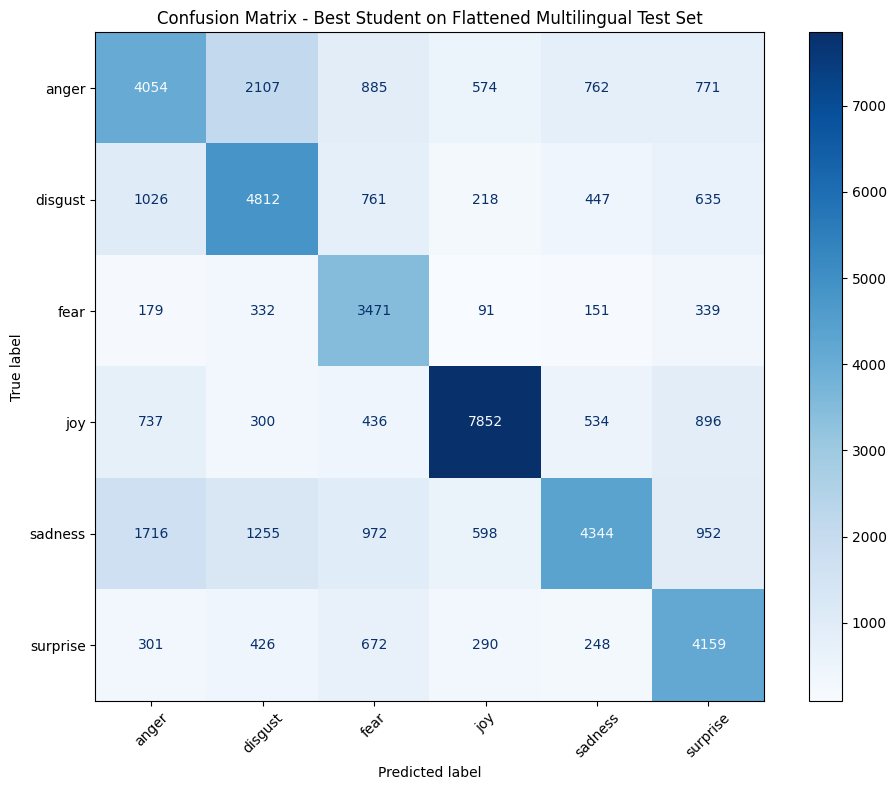

Executed cell #22


In [22]:
# ==========================================================
# CELL 22
# Evaluate the best student model on test data and plot confusion matrix
# ==========================================================

print("Starting cell #22")
print("Evaluating best student on test file:", TEST_CSV)

test_metrics = evaluate_classification_model(
    student_model,
    flat_test_loader,
    device
)

print(f"Test Loss: {test_metrics['loss']:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Test Precision: {test_metrics['precision_macro']:.4f}")
print(f"Test Recall: {test_metrics['recall_macro']:.4f}")
print(f"Test Macro F1: {test_metrics['macro_f1']:.4f}")
print(f"Test Weighted F1: {test_metrics['weighted_f1']:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_metrics["y_true"],
        test_metrics["y_pred"],
        target_names=label_encoder.classes_,
        digits=4
    )
)

cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"])

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix - Best Student on Flattened Multilingual Test Set")
plt.tight_layout()
plt.show()

print("Executed cell #22")

In [23]:
# ==========================================================
# CELL 23
# Save final lightweight student artifacts only
# FP32 + INT8 + tokenizer + label encoder + config
# ==========================================================

print("Starting cell #23")

def save_student_artifacts(student_model, tokenizer, label_encoder, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    base_model = get_base_model(student_model)

    fp32_path = os.path.join(save_dir, "student_fp32_state_dict.pt")
    torch.save(base_model.state_dict(), fp32_path)

    config_path = os.path.join(save_dir, "student_arch_config.json")
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(base_model.arch_config, f, indent=2)

    tokenizer_dir = os.path.join(save_dir, "tokenizer")
    tokenizer.save_pretrained(tokenizer_dir)

    label_path = os.path.join(save_dir, "label_encoder.pkl")
    with open(label_path, "wb") as f:
        pickle.dump(label_encoder, f)

    quantized_student = quantize_dynamic(
        copy.deepcopy(base_model).cpu().eval(),
        {nn.Linear},
        dtype=torch.qint8
    )

    int8_path = os.path.join(save_dir, "student_int8_state_dict.pt")
    torch.save(quantized_student.state_dict(), int8_path)

    print(f"Saved FP32 student to: {fp32_path}")
    print(f"Saved INT8 student to: {int8_path}")
    print(f"Saved tokenizer to: {tokenizer_dir}")
    print(f"Saved label encoder to: {label_path}")
    print(f"Saved student config to: {config_path}")

    if os.path.exists(fp32_path):
        print(f"FP32 checkpoint size: {os.path.getsize(fp32_path) / (1024 * 1024):.2f} MB")
    if os.path.exists(int8_path):
        print(f"INT8 checkpoint size: {os.path.getsize(int8_path) / (1024 * 1024):.2f} MB")

    return quantized_student

quantized_student = save_student_artifacts(
    student_model=student_model,
    tokenizer=tokenizer,
    label_encoder=label_encoder,
    save_dir=SAVE_DIR
)

print("Executed cell #23")

Starting cell #23
Saved FP32 student to: /kaggle/working/lightweight_multilingual_emotion_kd_student/student_fp32_state_dict.pt
Saved INT8 student to: /kaggle/working/lightweight_multilingual_emotion_kd_student/student_int8_state_dict.pt
Saved tokenizer to: /kaggle/working/lightweight_multilingual_emotion_kd_student/tokenizer
Saved label encoder to: /kaggle/working/lightweight_multilingual_emotion_kd_student/label_encoder.pkl
Saved student config to: /kaggle/working/lightweight_multilingual_emotion_kd_student/student_arch_config.json
FP32 checkpoint size: 899.24 MB
INT8 checkpoint size: 775.51 MB
Executed cell #23


In [24]:
# ==========================================================
# CELL 24
# Define loading helpers and a single-text prediction helper
# ==========================================================

print("Starting cell #24")

def load_student_fp32(save_dir, device):
    with open(os.path.join(save_dir, "student_arch_config.json"), "r", encoding="utf-8") as f:
        arch_config = json.load(f)

    tokenizer = AutoTokenizer.from_pretrained(os.path.join(save_dir, "tokenizer"))

    with open(os.path.join(save_dir, "label_encoder.pkl"), "rb") as f:
        label_encoder = pickle.load(f)

    model = TruncatedXLMRStudent(
        num_labels=arch_config["num_labels"],
        num_hidden_layers=arch_config["num_hidden_layers"],
        projection_dim=arch_config["projection_dim"],
        dropout=arch_config["dropout"],
        pretrained_model_name=arch_config["pretrained_model_name"],
        init_from_pretrained=False,
        encoder_config_dict=arch_config["encoder_config"]
    )

    state_dict = torch.load(
        os.path.join(save_dir, "student_fp32_state_dict.pt"),
        map_location=device
    )
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    if torch.cuda.is_available() and torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    return model, tokenizer, label_encoder

id_to_label = {i: label for i, label in enumerate(label_encoder.classes_)}

@torch.inference_mode()
def predict_single_text(text, model, tokenizer, max_length=MAX_LENGTH):
    model.eval()

    enc = tokenizer(
        [str(text)],
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )

    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = extract_logits(outputs)
        probs = torch.softmax(logits, dim=-1)[0].detach().cpu().numpy()

    pred_id = int(np.argmax(probs))
    return {
        "predicted_label": id_to_label[pred_id],
        "predicted_id": pred_id,
        "confidence": float(probs[pred_id]),
        "probabilities": {id_to_label[i]: float(probs[i]) for i in range(len(probs))}
    }

example_text = test_df.iloc[0]["English"]
example_pred = predict_single_text(example_text, student_model, tokenizer)

print("Example text:", example_text)
print("Predicted label:", example_pred["predicted_label"])
print("Confidence:", round(example_pred["confidence"], 4))

print("Executed cell #24")

Starting cell #24
Example text: have no words to say, the song and the video are the same. Go ahead, I am with you always. 👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍
Predicted label: joy
Confidence: 0.7967
Executed cell #24
